# The Shop Floor Swing-Jib Crane Fastener Validation

Department of Mechanical Engineering, Texas A&M University  
2026-05-26

## 1. Scenario Context & Design Space

You are a manufacturing engineer designing a compact, wall-mounted
swing-jib crane for an automotive assembly line. The crane is used to
lift battery packs into vehicle frames. Your engineering team must
decide whether a standard off-the-shelf fastener can be safely
implemented at the primary wall anchor bracket (Point $A$), or if it
will fail under shear load—causing catastrophic structural failure,
assembly line downtime, and severe safety hazards.

The crane must safely support a hanging payload of **600 lb** at its
furthest tip (Point $C$).

<table>
<colgroup>
<col style="width: 100%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div width="100.0%"
data-layout-align="left">
<figure>
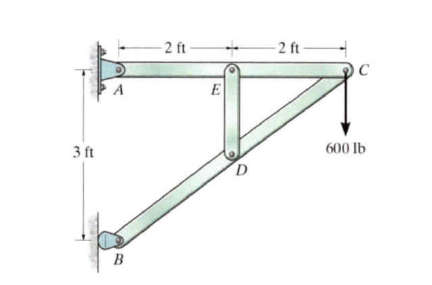
<figcaption aria-hidden="true">Wall-Mounted Crane Setup</figcaption>
</figure>
</div></td>
</tr>
</tbody>
</table>

Figure 1

------------------------------------------------------------------------

## 2. PHASE 1: PRE-NUMERICAL DIAGNOSTIC QUESTIONNAIRE & SOLUTION KEY

### Q1: Design & Commercialization Considerations

What real-world operational and environmental factors went into the
engineering design of this workshop crane? Consider aspect ratios,
footprint constraints on a crowded factory floor, worker safety margins,
and ease of installation or removal from a standard concrete pillar.

**Instructor Answer Key:** \* **Workspace Efficiency:** Wall-mounted jib
cranes maximize floor space by completely eliminating ground footprints
or intrusive gantry pillars. \* **Aspect Ratio & Reach:** A compact
vertical depth relative to horizontal outreach lets the crane swing
deeply into crowded assembly paths while clearing overhead facility
lines. \* **Modular Assembly:** Standardized pinning brackets (rather
than non-removable weldments) permit fast servicing and effortless
relocation during assembly line reconfigurations. \* **OSHA
Compliance:** Moving payloads directly above plant operators mandates
strict structural safety margins against sudden mechanical failure.

### Q2: Material Selection Framework

How should the material choice be made for the structural arms versus
the high-wear connection pins? What material properties (e.g.,
ductility, yield strength, shear strength, density) are prioritized to
prevent catastrophic, brittle failure while keeping manufacturing costs
competitive?

**Instructor Answer Key:** \* **Structural Arms (Beams AC/BC):** Sized
for a high stiffness-to-weight ratio and tensile yield strength
($\sigma_y$) using structural steel (A36) or aluminum (6061-T6). High
material ductility ensures visual bending indicators under extreme
overload rather than instantaneous brittle cleavage. \* **Connection
Fastening Pins:** Face aggressive localized bearing forces and extreme
cutting actions over small areas. Sizing prioritizes exceptional shear
yield strength ($\tau_y \approx 0.577\sigma_y$) and surface wear
hardness, utilizing high-strength alloy steels.

### Q3: Critical Geometrical Parameters

Identify the critical geometric parameters of the system. Which specific
dimensions govern the internal axial forces, which ones govern bending
or buckling vulnerabilities, and which ones dictate the shear planes of
the hardware?

**Instructor Answer Key:** \* **Axial Force Drivers:** The vertical
spacing between wall mounts ($H_{AB}$) and the triangulated angle of
strut $BC$. Shorter vertical boundaries cause horizontal reactions to
spike rapidly. \* **Buckling Drivers:** The unbraced length and
cross-sectional radius of gyration ($r$) of compression strut $BC$
dictate its resistance to elastic column buckling. \* **Shear Plane
Drivers:** The nominal pin diameter ($d$) dictates the cross-sectional
block area. Because bracket $A$ is a double-shear clevis configuration,
the boundary load splits across exactly two parallel shear surfaces
($A_{\text{pin}} = \pi d^2 / 4$).

### Q4: Loading Characteristics & Estimation

What kind of loading is this system subjected to? If it is lifting
automotive battery packs into vehicle frames, is the load truly static,
or is it time-varying/cyclic? How do dynamic shock factors (e.g., sudden
hoisting or stopping) affect your estimation of the design load compared
to the dead weight of the payload?

**Instructor Answer Key:** \* **Loading Classification:** Decideably
time-varying and cyclic. Components endure a discrete cycle each time a
payload is hitched, hoisted, swung, and lowered. \* **Dynamic Shock
Multiplier:** Quick braking or sudden hoist startup creates significant
inertial spikes. To calculate equivalent-static design loads, engineers
apply a shock factor:
$P_{\text{design}} = \mathcal{I} \cdot P_{\text{static}}$. Standard
practice mandates a minimum $15\%$ to $25\%$ overhead buffer
($\mathcal{I} = 1.15$ to $1.25$).

### Q5: Location Vulnerabilities, Strength, & Stiffness

- **Critical Locations:** Pinpoint the specific joints or cross-sections
  most vulnerable to failure. Where is the stress concentration highest?
- **Stiffness vs. Strength:** Does the horizontal arm require
  optimization primarily for **strength** (to prevent permanent plastic
  yielding) or for **stiffness** (to limit elastic deflection so the
  payload doesn’t sag or vibrate excessively during transport)?

**Instructor Answer Key:** \* **Vulnerable Regions:** Primary wall
interface connections (Joint $A$ and Joint $B$) carry the global
overturning cantilever moment. Pin-holes act as localized geometric
stress raisers ($K_t$), making them high risk for tear-out or bearing
failure. \* **Stiffness Optimization:** While the arm must possess
enough strength to avoid yielding, its dimensions are heavily driven by
stiffness limits. Insufficient flexural stiffness causes crane tip $C$
to sag, creating an unlevel track where heavy hanging loads drift
uncontrollably under gravity.

### Q6: Evaluation Criteria & Structural Metrics

What numerical criteria and material limits must you select to evaluate
the structural integrity of this system? When checking the main
structural members versus the fastening pins, should your factor of
safety be benchmarked against the **yield strength** ($\sigma_y$) or the
**ultimate tensile strength** ($\sigma_{ut}$)? Why?

**Instructor Answer Key:** \* **Evaluation Metrics:** Pins must be
evaluated using shear yield boundaries (von Mises or Tresca) against
shear yield strength ($\tau_y$). Structural arms are benchmarked against
tensile yield strength ($\sigma_y$). \* **Why Yield Over Ultimate:**
Sizing moving workspace machinery against ultimate tensile limits
($\sigma_{ut}$) is unsafe. Long before a ductile bar breaks, it
undergoes permanent, unrecoverable plastic elongation—distorting the
load path, triggering structural instability, and rendering the asset
inoperable.

------------------------------------------------------------------------

## 3. PHASE 2: NUMERICAL IMPLEMENTATION & OPTIMIZATION

Run the cells below to initialize the interactive verification toolkit
inside the computational kernel.

import ipywidgets as widgets from IPython.display import display,
Markdown, clear_output import numpy as np

# 1. Standard Materials Database Mapping

materials_db = { ‘A36 Structural Steel’: {‘sigma_y’: 36.0, ‘sigma_ut’:
58.0, ‘cost’: 1.0}, ‘6061-T6 Aluminum’: {‘sigma_y’: 40.0, ‘sigma_ut’:
45.0, ‘cost’: 2.2}, ‘AISI 1045 HR Steel’: {‘sigma_y’: 45.0, ‘sigma_ut’:
82.0, ‘cost’: 1.6} }

# 2. Standard SAE J429 Bolt Database (Allowable shear derived via von Mises shear yield with SF = 2.0)

bolts_db = { ‘SAE Grade 2 (Low Carbon Steel)’: {‘tau_allow’: 16.4}, ‘SAE
Grade 5 (Medium Carbon Tempered)’: {‘tau_allow’: 26.5}, ‘SAE Grade 8
(Alloy Steel, Quenched & Tempered)’: {‘tau_allow’: 37.5} }

# 3. Standard Coarse Size Series Mapping (Diameter vs Core Minor Tensile Root Shear Area)

standard_sizes = { ‘1/4" - 20 UNC’: {‘d’: 0.2500, ‘area’: 0.0318},
‘5/16" - 18 UNC’: {‘d’: 0.3125, ‘area’: 0.0524}, ‘3/8" - 16 UNC’: {‘d’:
0.3750, ‘area’: 0.0775}, ‘7/16" - 14 UNC’: {‘d’: 0.4375, ‘area’:
0.1063}, ‘1/2" - 13 UNC’: {‘d’: 0.5000, ‘area’: 0.1419}, ‘5/8" - 11
UNC’: {‘d’: 0.6250, ‘area’: 0.2260} }

mat_dropdown = widgets.Dropdown(options=list(materials_db.keys()),
description=‘Beam Material:’, style={‘description_width’: ‘initial’})
bolt_dropdown = widgets.Dropdown(options=list(bolts_db.keys()),
description=‘Fastener Grade:’, style={‘description_width’: ‘initial’})
size_dropdown = widgets.Dropdown(options=list(standard_sizes.keys()),
description=‘Standard Bolt Size:’, style={‘description_width’:
‘initial’})

ui = widgets.VBox(\[mat_dropdown, bolt_dropdown, size_dropdown\])
display(ui)